In [42]:

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

In [ ]:
def calculate_probabilities(graph: nx.Graph) -> dict[int, float]:
    """berekent de kans voor iedere link
    gemaakt door Sven"""
    
    degrees = dict(graph.degree())
    total_degree = sum(degrees.values())

    probabilities = {}

    for node in degrees:
        probabilities[node] = degrees[node] / total_degree

    return probabilities

In [ ]:
def choose_nodes(G: nx.graph, M: int)->list[int]:
    """kiest welke notes er gekozen worden om mee te verbinden
    gemaakt door Sven"""
    chosen_nodes = []
    probabilities = calculate_probabilities(G)

    for _ in range(M):
        chosen_node = random.choices(list(probabilities.keys()),
        weights=list(probabilities.values()), k=1)
        
        chosen_node = chosen_node[0]
        
        chosen_nodes.append(chosen_node)

        probabilities.pop(chosen_node)

        total_probability = sum(probabilities.values())

        for node in probabilities:
            probabilities[node] = probabilities[node] / total_probability
            
    return chosen_nodes


In [ ]:
def generate_network(K: int, N: int, M: int) -> nx.Graph:
    """maakt het Barabási-Albert-netwerk\
    gemaakt door Sven"""
    G = nx.Graph()
    G.add_nodes_from(range(1,K+1))
    for i in range(2,K+1):
        G.add_edge(1,i)

    for new_node in range(K + 1, N + 1):
        chosen_nodes = choose_nodes(G,M)

        for node in chosen_nodes:
            G.add_edge(new_node, node)

    return G



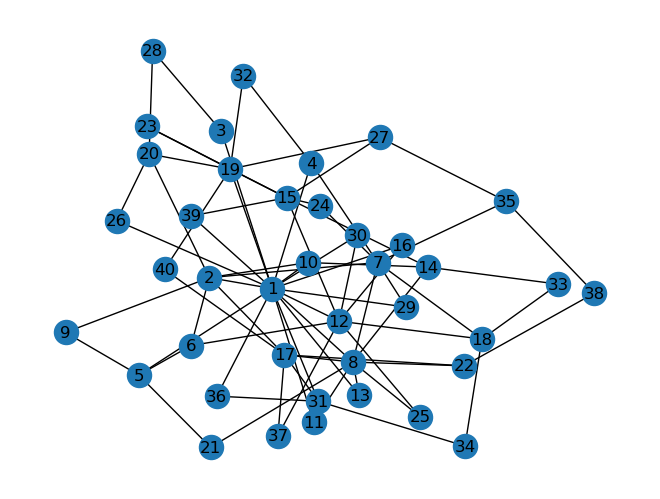

In [109]:
plot = generate_network(5,40,2)
nx.draw(plot, with_labels=True)
plt.show()